In [1]:
import numpy as np
import math
from math import sqrt, exp, pi
from statistics import NormalDist
import joblib
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import joblib

In [2]:
emp_data_100 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_n2100_1000.pkl")
emp_data_200 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_n2200_1000.pkl")
emp_data_400 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_n2400_1000.pkl")
emp_data_ify = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results.pkl")

In [5]:
emp_data_100["loss_fil_x_all"]

array([[0.00624889, 0.00373752, 0.00216584, ..., 0.00800752, 0.00783867,
        0.00838454],
       [0.00713234, 0.00348955, 0.00280053, ..., 0.00828251, 0.00810132,
        0.00809338],
       [0.00579398, 0.00389647, 0.00240145, ..., 0.00783516, 0.00910015,
        0.00784737],
       ...,
       [0.02608999, 0.04079845, 0.05006851, ..., 0.01099919, 0.01102027,
        0.01081356],
       [0.02606887, 0.04029172, 0.05050914, ..., 0.01181567, 0.01180169,
        0.01084799],
       [0.02816225, 0.04206822, 0.05029517, ..., 0.01123649, 0.01166295,
        0.01144743]])

In [2]:
theo_data_100 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_n2100.pkl")
theo_data_200 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_n2200.pkl")
theo_data_400 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_n2400.pkl")
theo_data_ify = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo.pkl")

In [3]:
theo_data_100 = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_n2100_2.pkl")

In [4]:
theo_data_100

{'bias': array([0.  , 0.  , 0.  , ..., 0.25, 0.25, 0.25]),
 'width': array([0.01      , 0.02334448, 0.03668896, ..., 3.97331104, 3.98665552,
        4.        ]),
 'which_min': array([0, 0, 0, ..., 3, 3, 3]),
 'loss_fil_x_all': array([2.08885864e-05, 4.87635028e-05, 7.66388534e-05, ...,
        1.14564946e-02, 1.14037855e-02, 1.13521749e-02]),
 'loss_fil_y_all': array([2.08885871e-05, 4.87635234e-05, 7.66389792e-05, ...,
        1.72434011e-02, 1.72273071e-02, 1.72122021e-02]),
 'loss_fil_xy_all': array([2.08885864e-05, 4.87635029e-05, 7.66388543e-05, ...,
        2.34289759e-02, 2.32950590e-02, 2.31633851e-02]),
 'loss_unf_x_all': array([0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01])}

In [ ]:
data = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_2.pkl")

## theoritical result

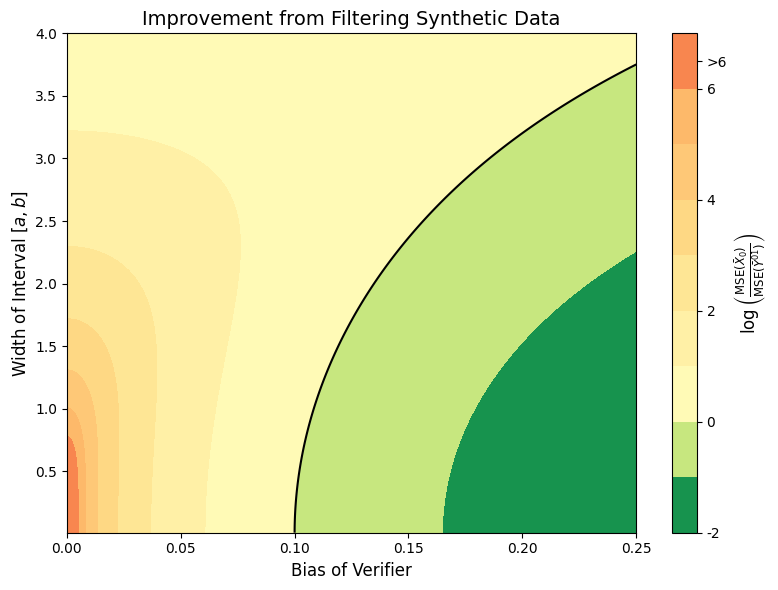

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib

# 加载数据
data = joblib.load("/Users/qiyuanliu/Desktop/model_collapse/simulation_results_theo_2.pkl")

bias = data['bias']
width = data['width']
loss_fil_y_all = data['loss_fil_y_all']
loss_unf_x_all = data['loss_unf_x_all']

# 计算性能提升（正值代表过滤后更好）
log_improvement = np.log(loss_unf_x_all / loss_fil_y_all)

# 构建网格
bias_unique = np.unique(bias)
width_unique = np.unique(width)
n_bias = len(bias_unique)
n_width = len(width_unique)
log_improvement_grid = log_improvement.reshape((n_bias, n_width)).T

# 设定颜色映射，绿色为好，红色为差
vmin = np.min(log_improvement)
vmax = np.max(log_improvement)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# 画图
plt.figure(figsize=(8, 6))
#levels = np.linspace(-2, 16, 19)
#
levels = np.concatenate([
    np.linspace(-2, 6, 9), 
    [10]            
])
contour = plt.contourf(
    bias_unique, width_unique, log_improvement_grid,
    levels=levels, cmap='RdYlGn_r', norm=norm
)

# 加上0线（无提升）
plt.contour(bias_unique, width_unique, log_improvement_grid, levels=[0], colors='black', linewidths=1.5)

# 色条
cbar = plt.colorbar(contour, ticks=[-2, 0, 2, 4, 6, 8])
cbar.ax.set_yticklabels(['-2', '0', '2', '4', '6', '>6'])
cbar.set_label(r'$\log \left( \frac{\mathrm{MSE}(\bar{X}_0)}{\mathrm{MSE}(\bar{Y}^{01})} \right)$', fontsize=12)

# 标签和标题
plt.xlabel(r'Bias of Verifier', fontsize=12)
plt.ylabel(r'Width of Interval $[a, b]$', fontsize=12)
plt.title('Improvement from Filtering Synthetic Data()', fontsize=14)
plt.tight_layout()
plt.show()


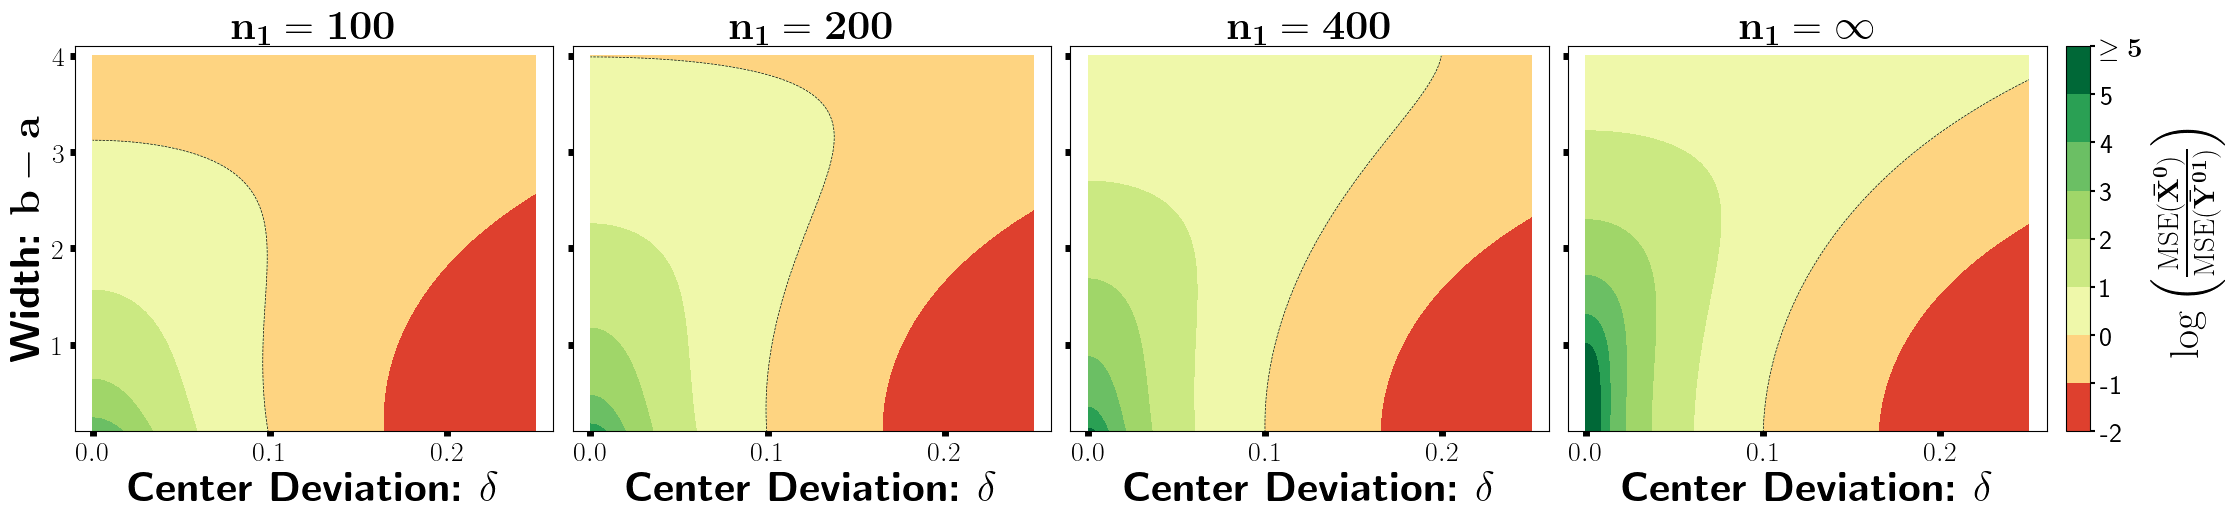

<Figure size 640x480 with 0 Axes>

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

# --- Matplotlib 字体设置 ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- 数据路径与标签 ---
files = [
    ("simulation_results_theo_n2100_2.pkl", r"$\mathbf{n_1 = 100}$"),
    ("simulation_results_theo_n2200_2.pkl", r"$\mathbf{n_1 = 200}$"),
    ("simulation_results_theo_n2400_2.pkl", r"$\mathbf{n_1 = 400}$"),
    ("simulation_results_theo_2.pkl",       r"$\mathbf{n_1 = \infty}$")
]

# --- 色阶设置 ---
vmin = -2
vmax = 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# --- 构建 figure 和布局 ---
fig = plt.figure(figsize=(26, 5))  # 最终图与原始 4x5 保持一致，保留 colorbar 空间
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])  # colorbar 专用轴

# --- 绘图 ---
for j, (ax, (file_path, title)) in enumerate(zip(axes, files)):
    data = joblib.load(file_path)
    bias = data['bias']
    width = data['width']
    loss_fil_y_all = data['loss_fil_y_all']
    loss_unf_x_all = data['loss_unf_x_all']

    log_improvement = np.log(loss_unf_x_all / loss_fil_y_all)
    bias_unique = np.unique(bias)
    width_unique = np.unique(width)
    log_improvement_grid = log_improvement.reshape(len(bias_unique), len(width_unique)).T

    contour = ax.contourf(
        bias_unique, width_unique, log_improvement_grid,
        levels=levels, cmap='RdYlGn', norm=norm
    )

    ax.contour(bias_unique, width_unique, log_improvement_grid,
               levels=[0], colors='black', linewidths=0.5, linestyles='dashed')

    # 设置标签与样式
    ax.set_title(title, fontsize=30, fontweight='bold')
    #ax.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)
    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Colorbar ---
cbar = fig.colorbar(contour, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{Y}^{01})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'], fontsize=20)
cbar.ax.tick_params(labelsize=20, width=1.5)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# --- 展示 ---
plt.show()
plt.savefig("fig_theo_bold_y01.png", bbox_inches='tight', dpi=300)


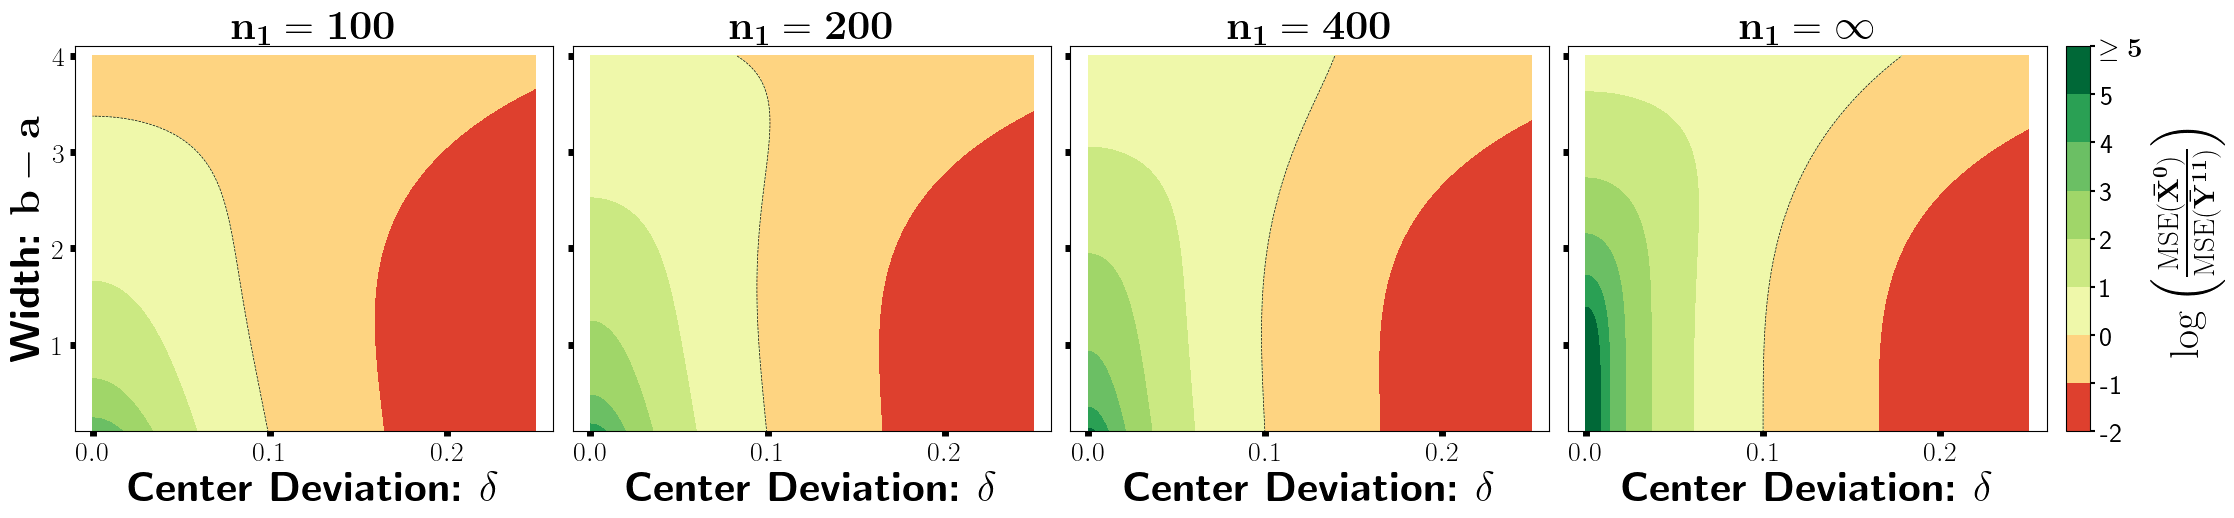

<Figure size 640x480 with 0 Axes>

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

# --- Matplotlib 字体设置 ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- 数据路径与标签 ---
files = [
    ("simulation_results_theo_n2100_2.pkl", r"$\mathbf{n_1 = 100}$"),
    ("simulation_results_theo_n2200_2.pkl", r"$\mathbf{n_1 = 200}$"),
    ("simulation_results_theo_n2400_2.pkl", r"$\mathbf{n_1 = 400}$"),
    ("simulation_results_theo_2.pkl",       r"$\mathbf{n_1 = \infty}$")
]

# --- 色阶设置 ---
vmin = -2
vmax = 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# --- 构建 figure 和布局 ---
fig = plt.figure(figsize=(26, 5))
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])

# --- 绘图 ---
for j, (ax, (file_path, title)) in enumerate(zip(axes, files)):
    data = joblib.load(file_path)
    bias = data['bias']
    width = data['width']
    loss_fil_y_all = data['loss_fil_xy_all']
    loss_unf_x_all = data['loss_unf_x_all']

    log_improvement = np.log(loss_unf_x_all / loss_fil_y_all)
    bias_unique = np.unique(bias)
    width_unique = np.unique(width)
    log_improvement_grid = log_improvement.reshape(len(bias_unique), len(width_unique)).T

    contour = ax.contourf(
        bias_unique, width_unique, log_improvement_grid,
        levels=levels, cmap='RdYlGn', norm=norm
    )

    ax.contour(bias_unique, width_unique, log_improvement_grid,
               levels=[0], colors='black', linewidths=0.5, linestyles='dashed')

    # 设置标签与样式
    ax.set_title(title, fontsize=30, fontweight='bold')
    #ax.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)
    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Colorbar ---
cbar = fig.colorbar(contour, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{Y}^{11})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=20, width=1.5)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# --- 展示 ---
plt.show()
plt.savefig("fig_theo_bold_y11.png", bbox_inches='tight', dpi=300)


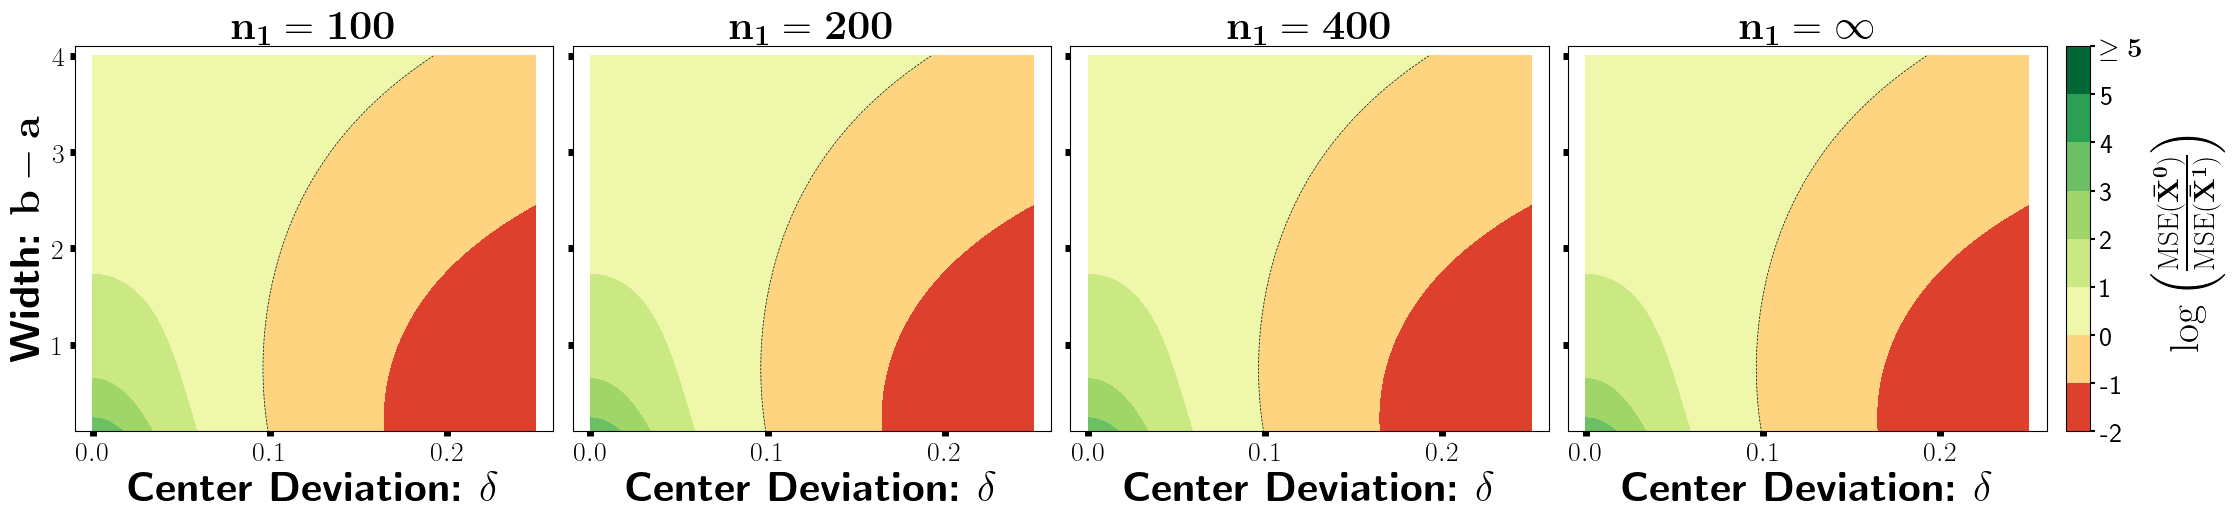

<Figure size 640x480 with 0 Axes>

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

# --- Matplotlib 字体设置 ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- 数据路径与标签 ---
files = [
    ("simulation_results_theo_n2100_2.pkl", r"$\mathbf{n_1 = 100}$"),
    ("simulation_results_theo_n2200_2.pkl", r"$\mathbf{n_1 = 200}$"),
    ("simulation_results_theo_n2400_2.pkl", r"$\mathbf{n_1 = 400}$"),
    ("simulation_results_theo_2.pkl",       r"$\mathbf{n_1 = \infty}$")
]

# --- 色阶设置 ---
vmin = -2
vmax = 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# --- 构建 figure 和布局 ---
fig = plt.figure(figsize=(26, 5))
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])

# --- 绘图 ---
for j, (ax, (file_path, title)) in enumerate(zip(axes, files)):
    data = joblib.load(file_path)
    bias = data['bias']
    width = data['width']
    loss_fil_y_all = data['loss_fil_x_all']
    loss_unf_x_all = data['loss_unf_x_all']

    log_improvement = np.log(loss_unf_x_all / loss_fil_y_all)
    bias_unique = np.unique(bias)
    width_unique = np.unique(width)
    log_improvement_grid = log_improvement.reshape(len(bias_unique), len(width_unique)).T

    contour = ax.contourf(
        bias_unique, width_unique, log_improvement_grid,
        levels=levels, cmap='RdYlGn', norm=norm
    )

    ax.contour(bias_unique, width_unique, log_improvement_grid,
               levels=[0], colors='black', linewidths=0.5, linestyles='dashed')

    # 设置标签与样式
    ax.set_title(title, fontsize=30, fontweight='bold')
    #ax.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)
    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Colorbar ---
cbar = fig.colorbar(contour, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{X}^{1})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=20, width=1.5)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# --- 展示 ---
plt.show()
plt.savefig("fig_theo_bold_y01.png", bbox_inches='tight', dpi=300)


## empirical result

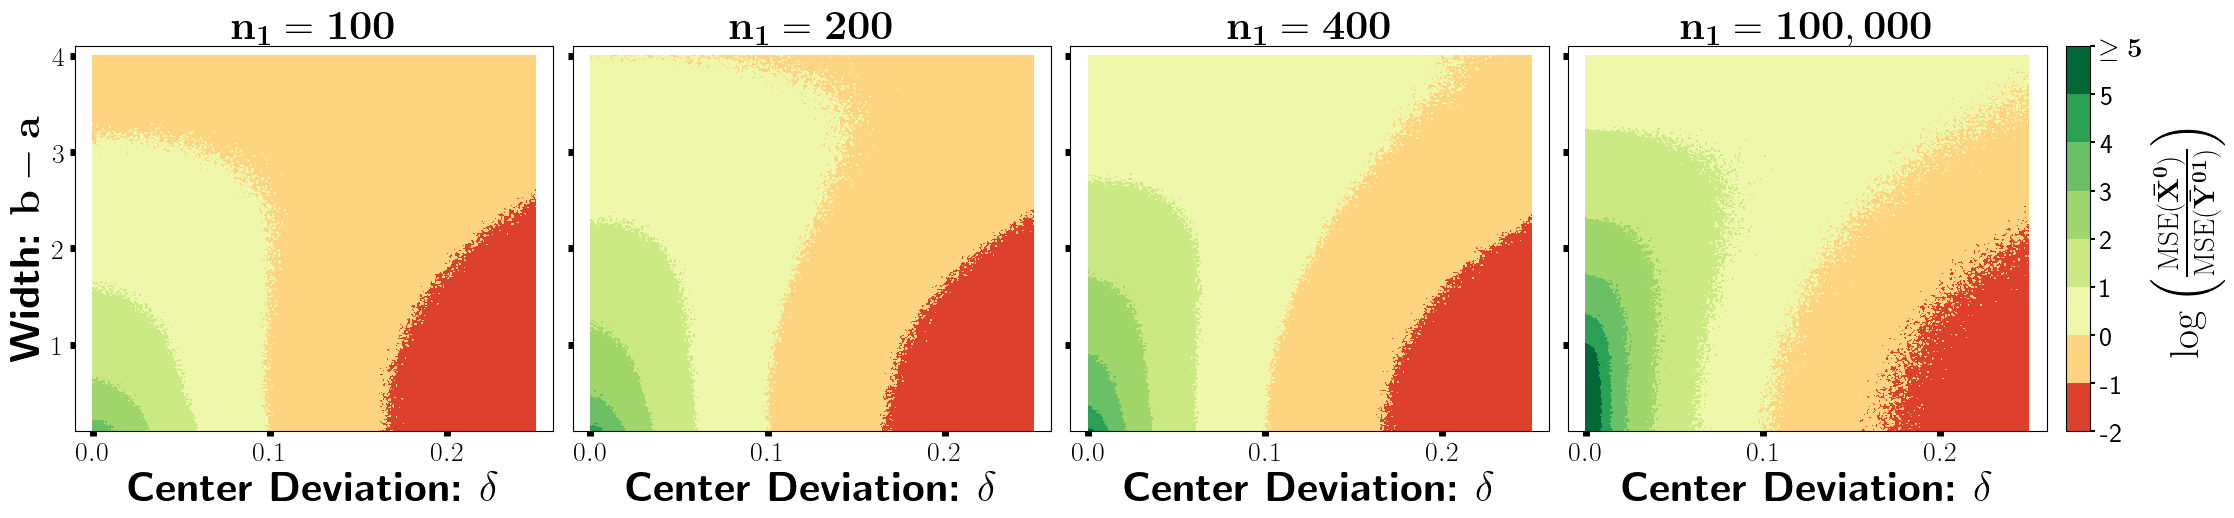

<Figure size 640x480 with 0 Axes>

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

# 全局字体设置
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# 数据路径与标签
empirical_files = [
    ("simulation_results_n2100_1000.pkl", "n = 100"),
    ("simulation_results_n2200_1000.pkl", "n = 200"),
    ("simulation_results_n2400_1000.pkl", "n = 400"),
    ("simulation_results.pkl",            "n = ∞")
]
n2_labels = [r"$\mathbf{n_1 = 100}$", r"$\mathbf{n_1 = 200}$", r"$\mathbf{n_1 = 400}$", r"$\mathbf{n_1 = 100,000}$"]

# 网格
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)
bias_array = np.tile(bias_vals, n_width)
width_array = np.repeat(width_vals, n_bias)

# 色阶设置
vmin, vmax = -2, 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# 创建 figure 和 gridspec 布局（5列，第5列给 colorbar）
fig = plt.figure(figsize=(26, 5))  # 最终图与原始 4x5 保持一致，保留 colorbar 空间
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])  # colorbar 专用轴

#fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)
# 绘图
for j, (ax, (file_path, _)) in enumerate(zip(axes, empirical_files)):
    data = joblib.load(file_path)
    loss_fil_x_all = data['loss_fil_y_all']
    loss_unf_x_all = data['loss_unf_x_all']
    log_improvement = np.log(loss_unf_x_all / loss_fil_x_all)
    log_improvement_grid = log_improvement.reshape(n_bias, n_width).T

    contour = ax.contourf(
        bias_vals, width_vals, log_improvement_grid,
        levels=levels, cmap='RdYlGn', norm=norm
    )

    #ax.contour(
    #    bias_vals, width_vals, log_improvement_grid,
    #    levels=[0], colors='black', linewidths=0.5, linestyles='dashed'
    #)

    # 坐标轴与标题
    ax.set_title(n2_labels[j], fontsize=30, fontweight='bold')
    #ax.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")
        
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)

    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
# 添加 colorbar 到专用 cax 轴
cbar = fig.colorbar(contour, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{Y}^{01})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=20, width=1.5)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# 展示或保存
plt.show()
plt.savefig("fig_empirical_bold_y01.png", bbox_inches='tight', dpi=300)


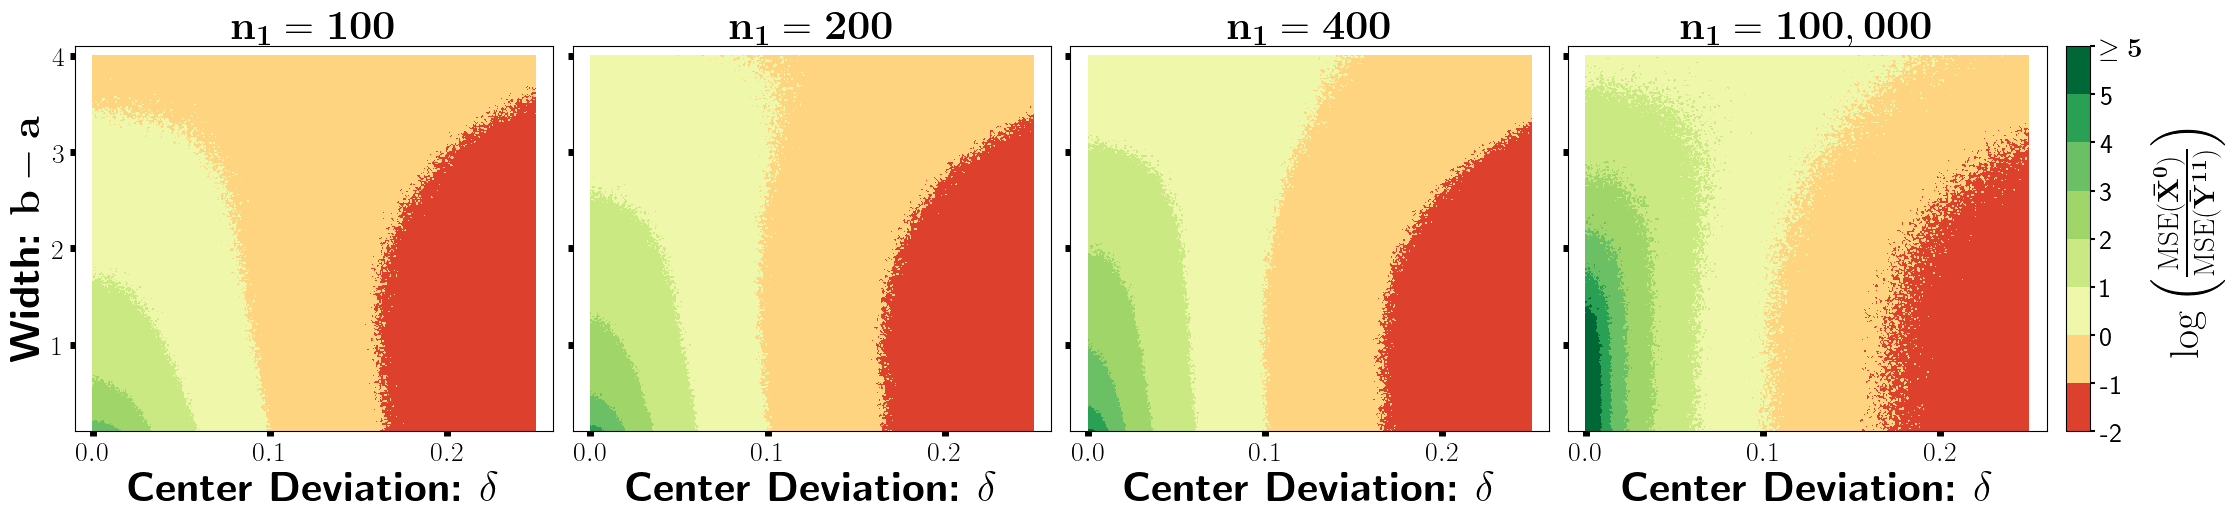

<Figure size 640x480 with 0 Axes>

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

# 全局字体设置
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# 数据路径与标签
empirical_files = [
    ("simulation_results_n2100_1000.pkl", "n = 100"),
    ("simulation_results_n2200_1000.pkl", "n = 200"),
    ("simulation_results_n2400_1000.pkl", "n = 400"),
    ("simulation_results.pkl",            "n = ∞")
]
n2_labels = [r"$\mathbf{n_1 = 100}$", r"$\mathbf{n_1 = 200}$", r"$\mathbf{n_1 = 400}$", r"$\mathbf{n_1 = 100,000}$"]

# 网格
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)
bias_array = np.tile(bias_vals, n_width)
width_array = np.repeat(width_vals, n_bias)

# 色阶设置
vmin, vmax = -2, 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# 创建 figure 和 gridspec 布局（5列，第5列给 colorbar）
fig = plt.figure(figsize=(26, 5))  # 最终图与原始 4x5 保持一致，保留 colorbar 空间
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])  # colorbar 专用轴

#fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)
# 绘图
for j, (ax, (file_path, _)) in enumerate(zip(axes, empirical_files)):
    data = joblib.load(file_path)
    loss_fil_x_all = data['loss_fil_xy_all']
    loss_unf_x_all = data['loss_unf_x_all']
    log_improvement = np.log(loss_unf_x_all / loss_fil_x_all)
    log_improvement_grid = log_improvement.reshape(n_bias, n_width).T

    contour = ax.contourf(
        bias_vals, width_vals, log_improvement_grid,
        levels=levels, cmap='RdYlGn', norm=norm
    )

    #ax.contour(
    #    bias_vals, width_vals, log_improvement_grid,
    #    levels=[0], colors='black', linewidths=0.5, linestyles='dashed'
    #)

    # 坐标轴与标题
    ax.set_title(n2_labels[j], fontsize=30, fontweight='bold')
    #ax.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")
        
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)

    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
# 添加 colorbar 到专用 cax 轴
cbar = fig.colorbar(contour, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{Y}^{11})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=20, width=1.5)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# 展示或保存
plt.show()
plt.savefig("fig_empirical_bold_y11.png", bbox_inches='tight', dpi=300)


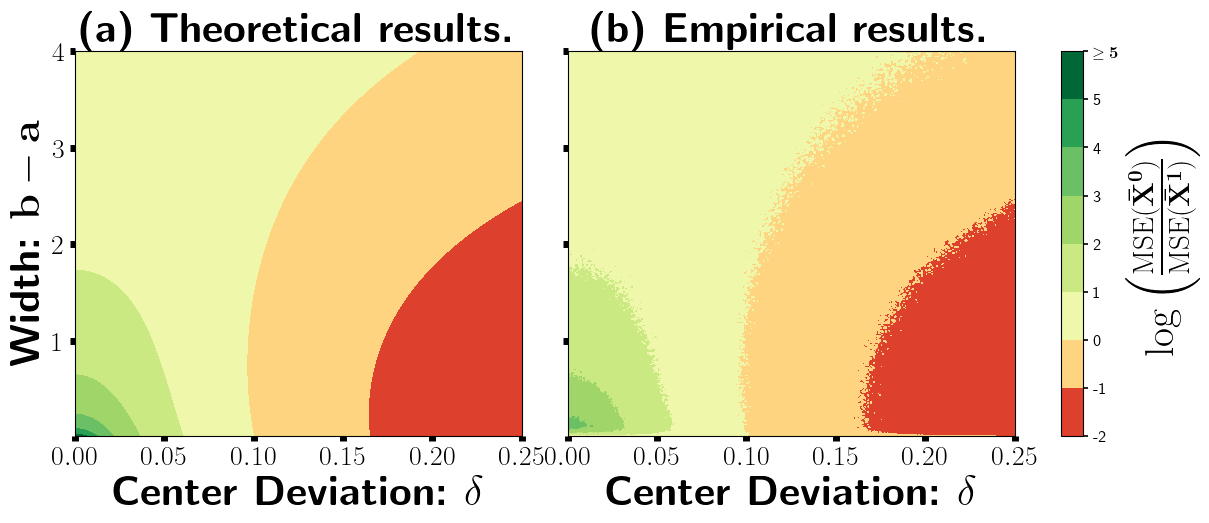

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# Load data
file_theo = "simulation_results_theo_n2100_2.pkl"
file_emp  = "simulation_results_n2100_1000.pkl"

# Grid setup
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)

vmin, vmax = -2, 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# Load theoretical
data_theo = joblib.load(file_theo)
log_imp_theo = np.log(data_theo['loss_unf_x_all'] / data_theo['loss_fil_x_all']).reshape(n_bias, n_width).T

# Load empirical
data_emp = joblib.load(file_emp)
log_imp_emp = np.log(data_emp['loss_unf_x_all'] / data_emp['loss_fil_x_all']).reshape(n_bias, n_width).T

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
# Theoretical plot
ax1 = fig.add_subplot(gs[0, 0])
c1 = ax1.contourf(bias_vals, width_vals, log_imp_theo, levels=levels, cmap='RdYlGn', norm=norm)
ax1.set_title(r"\textbf{(a) Theoretical results.}", fontsize=30, fontweight='bold')
#ax1.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=14, fontweight='bold')
ax1.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax1.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
ax1.tick_params(axis='both', labelsize=20, width=5)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')

# Empirical plot
ax2 = fig.add_subplot(gs[0, 1])
c2 = ax2.contourf(bias_vals, width_vals, log_imp_emp, levels=levels, cmap='RdYlGn', norm=norm)
ax2.set_title(r"\textbf{(b) Empirical results.}", fontsize=30, fontweight='bold')
#ax2.set_xlabel(r'\textbf{Bias:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax2.set_yticklabels([])  # Avoid double ylabel
ax2.tick_params(axis='both', labelsize=20, width=5)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')

# Colorbar
cbar = plt.colorbar(c2, cax=fig.add_subplot(gs[0, 2]))
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{X}^{1})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=12)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15, wspace=0.2)

plt.show()


Text(0.5, -0.25, '\\textbf{(b) Empirical results.}')

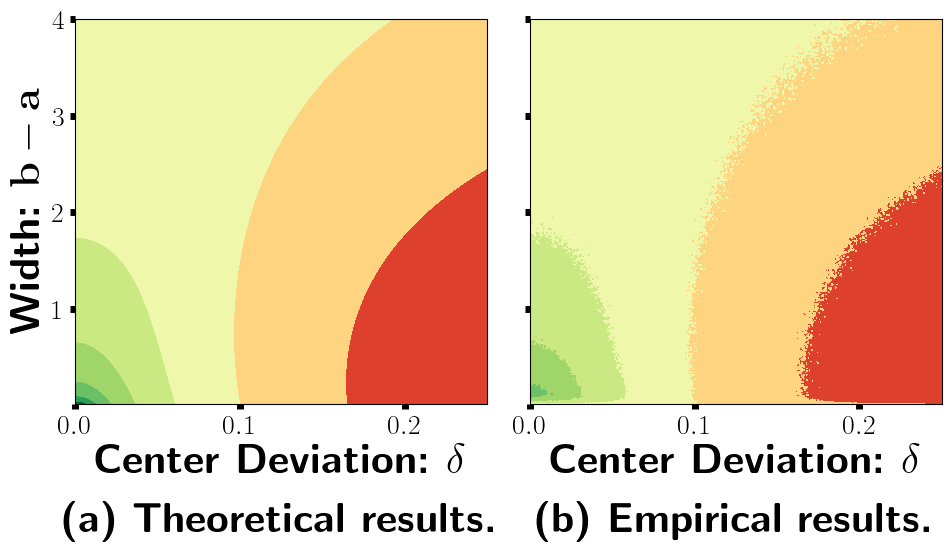

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# Load data
file_theo = "simulation_results_theo_n2100_2.pkl"
file_emp  = "simulation_results_n2100_1000.pkl"

# Grid setup
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)

vmin, vmax = -2, 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# Load theoretical
data_theo = joblib.load(file_theo)
log_imp_theo = np.log(data_theo['loss_unf_x_all'] / data_theo['loss_fil_x_all']).reshape(n_bias, n_width).T

# Load empirical
data_emp = joblib.load(file_emp)
log_imp_emp = np.log(data_emp['loss_unf_x_all'] / data_emp['loss_fil_x_all']).reshape(n_bias, n_width).T

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)


# Theoretical plot
ax1 = fig.add_subplot(gs[0, 0])
c1 = ax1.contourf(bias_vals, width_vals, log_imp_theo, levels=levels, cmap='RdYlGn', norm=norm)
ax1.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax1.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
ax1.tick_params(axis='both', labelsize=20, width=5)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')
# Add title below
ax1.text(0.5, -0.25, r"\textbf{(a) Theoretical results.}", transform=ax1.transAxes,
         ha='center', va='top', fontsize=30, fontweight='bold')

# Empirical plot
ax2 = fig.add_subplot(gs[0, 1])
c2 = ax2.contourf(bias_vals, width_vals, log_imp_emp, levels=levels, cmap='RdYlGn', norm=norm)
ax2.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax2.set_yticklabels([])  # Avoid double ylabel
ax2.tick_params(axis='both', labelsize=20, width=5)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')
# Add title below
#ax2.text(0.5, -0.25, r"\textbf{(b) Empirical results.}", transform=ax2.transAxes,
 #        ha='center', va='top', fontsize=30, fontweight='bold')
ax2.text(0.5, -0.25, r"\textbf{(b) Empirical results.}", transform=ax2.transAxes,
         ha='center', va='top', fontsize=30, fontweight='bold')

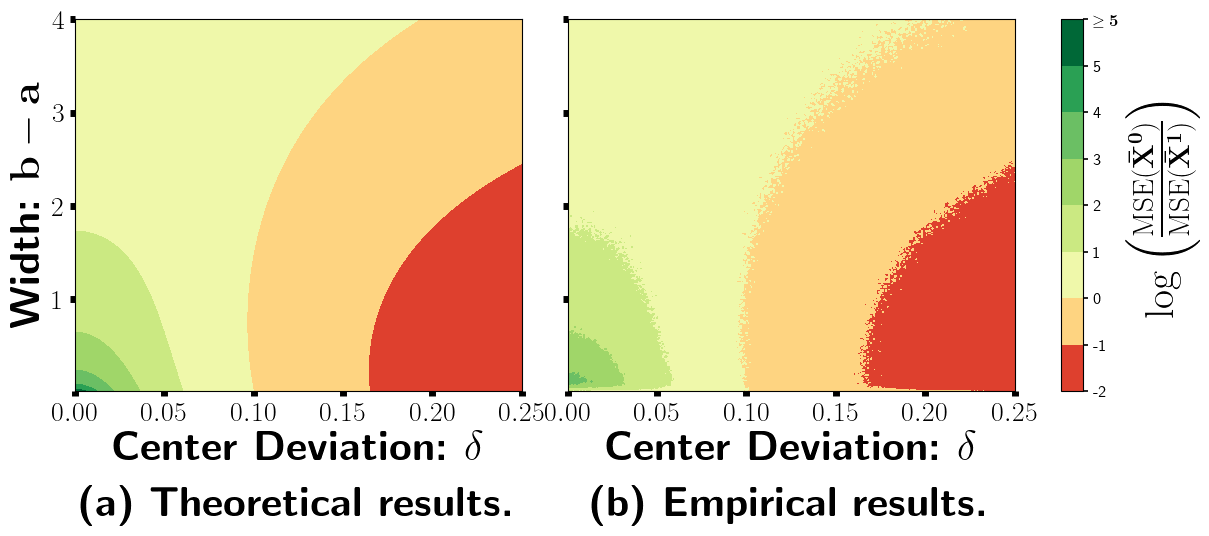

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import joblib

plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# Load data
file_theo = "simulation_results_theo_n2100_2.pkl"
file_emp  = "simulation_results_n2100_1000.pkl"

# Grid setup
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)

vmin, vmax = -2, 6
levels = [-2, -1, 0, 1, 2, 3, 4, 5, 100]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# Load theoretical
data_theo = joblib.load(file_theo)
log_imp_theo = np.log(data_theo['loss_unf_x_all'] / data_theo['loss_fil_x_all']).reshape(n_bias, n_width).T

# Load empirical
data_emp = joblib.load(file_emp)
log_imp_emp = np.log(data_emp['loss_unf_x_all'] / data_emp['loss_fil_x_all']).reshape(n_bias, n_width).T

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)

# Theoretical plot
ax1 = fig.add_subplot(gs[0, 0])
c1 = ax1.contourf(bias_vals, width_vals, log_imp_theo, levels=levels, cmap='RdYlGn', norm=norm)
ax1.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax1.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')
ax1.tick_params(axis='both', labelsize=20, width=5)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight('bold')
ax1.text(0.5, -0.25, r"\textbf{(a) Theoretical results.}", transform=ax1.transAxes,
         ha='center', va='top', fontsize=30, fontweight='bold')

# Empirical plot
ax2 = fig.add_subplot(gs[0, 1])
c2 = ax2.contourf(bias_vals, width_vals, log_imp_emp, levels=levels, cmap='RdYlGn', norm=norm)
ax2.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
ax2.set_yticklabels([])
ax2.tick_params(axis='both', labelsize=20, width=5)
for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontweight('bold')
ax2.text(0.5, -0.25, r"\textbf{(b) Empirical results.}", transform=ax2.transAxes,
         ha='center', va='top', fontsize=30, fontweight='bold')

# Colorbar
cbar_ax = fig.add_subplot(gs[0, 2])
cbar = plt.colorbar(c2, cax=cbar_ax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{\mathrm{MSE}(\bar{X}^0)}{\mathrm{MSE}(\bar{X}^{1})} \right)}$',
    fontsize=30, fontweight='bold'
)
cbar.ax.set_yticklabels(['-2','-1','0','1','2','3','4','5', r'$\mathbf{\geq 5}$'])
cbar.ax.tick_params(labelsize=12)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')

# Adjust layout to avoid title cropping
fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.3, wspace=0.2)

plt.show()


# Best strategy

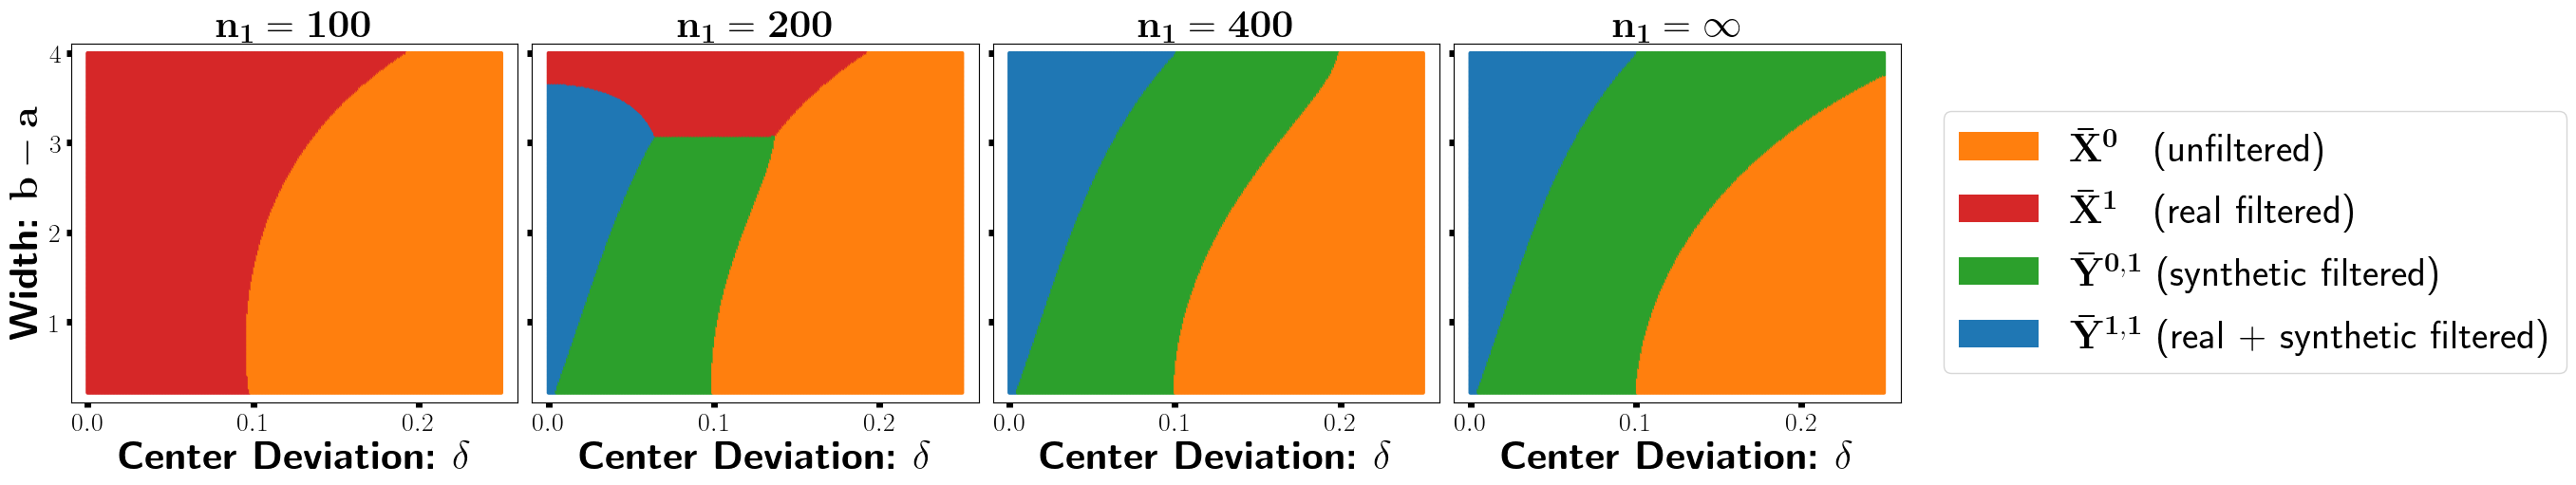

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import joblib

# --- Optional: Global font settings for bold text and ticks ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- Load data ---
emp_data_100 = joblib.load("simulation_results_n2100_1000.pkl")
emp_data_200 = joblib.load("simulation_results_n2200_1000.pkl")
emp_data_400 = joblib.load("simulation_results_n2400_1000.pkl")
emp_data_ify = joblib.load("simulation_results.pkl")

theo_data_100 = joblib.load("simulation_results_theo_n2100.pkl")
theo_data_200 = joblib.load("simulation_results_theo_n2200.pkl")
theo_data_400 = joblib.load("simulation_results_theo_n2400.pkl")
theo_data_ify = joblib.load("simulation_results_theo.pkl")

# --- Grid & filtering ---
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)
B, W = np.meshgrid(bias_vals, width_vals, indexing='ij')
bias_array = B.flatten()
width_array = W.flatten()
width_cut_mask = width_array >= 0.2
bias_array_cut = bias_array[width_cut_mask]
width_array_cut = width_array[width_cut_mask]

# --- Colormap (consistent with label order) ---
cmap = mcolors.ListedColormap(['#D62728', '#2CA02C', '#1F77B4', '#FF7F0E'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Panel titles ---
n2_labels = [r"$\mathbf{n_1 = 100}$", r"$\mathbf{n_1 = 200}$", r"$\mathbf{n_1 = 400}$", r"$\mathbf{n_1 = \infty}$"]


legend_handles = [
    Patch(facecolor='#FF7F0E', label=r'$\mathbf{\bar{X}^0}$\hspace*{0.6em} (unfiltered)'),
    Patch(facecolor='#D62728', label=r'$\mathbf{\bar{X}^1}$\hspace*{0.6em}  (real filtered)'),
    Patch(facecolor='#2CA02C', label=r'$\mathbf{\bar{Y}^{0,1}}$\hspace*{0em} (synthetic filtered)'),
    Patch(facecolor='#1F77B4', label=r'$\mathbf{\bar{Y}^{1,1}}$\hspace*{0em} (real + synthetic filtered)'),
]

# --- Theoretical Data ---
theo_data = [theo_data_100["which_min"], theo_data_200["which_min"],
             theo_data_400["which_min"], theo_data_ify["which_min"]]

# --- Create figure ---
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)

for j, ax in enumerate(axes1):
    which_flat = theo_data[j].flatten()
    which_cut = which_flat[width_cut_mask]

    ax.scatter(bias_array_cut, width_array_cut, c=which_cut,
               cmap=cmap, norm=norm, s=8, edgecolors='none')

    ax.set_title(n2_labels[j], fontsize=30, fontweight='bold')
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)

    #ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{|\frac{a + b}{2} - \mu|}$', fontsize=30, fontweight='bold')
    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')

    # Bold tick numbers
    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Shared legend (reordered) ---
fig1.legend(handles=legend_handles,
            loc='center left',
            bbox_to_anchor=(1.01, 0.5),
            frameon=True,
            fontsize=30)

# --- Save as high-res vector PDF ---
fig1.savefig("fig_theoretical_bold.png", bbox_inches='tight', dpi=300)
plt.show()


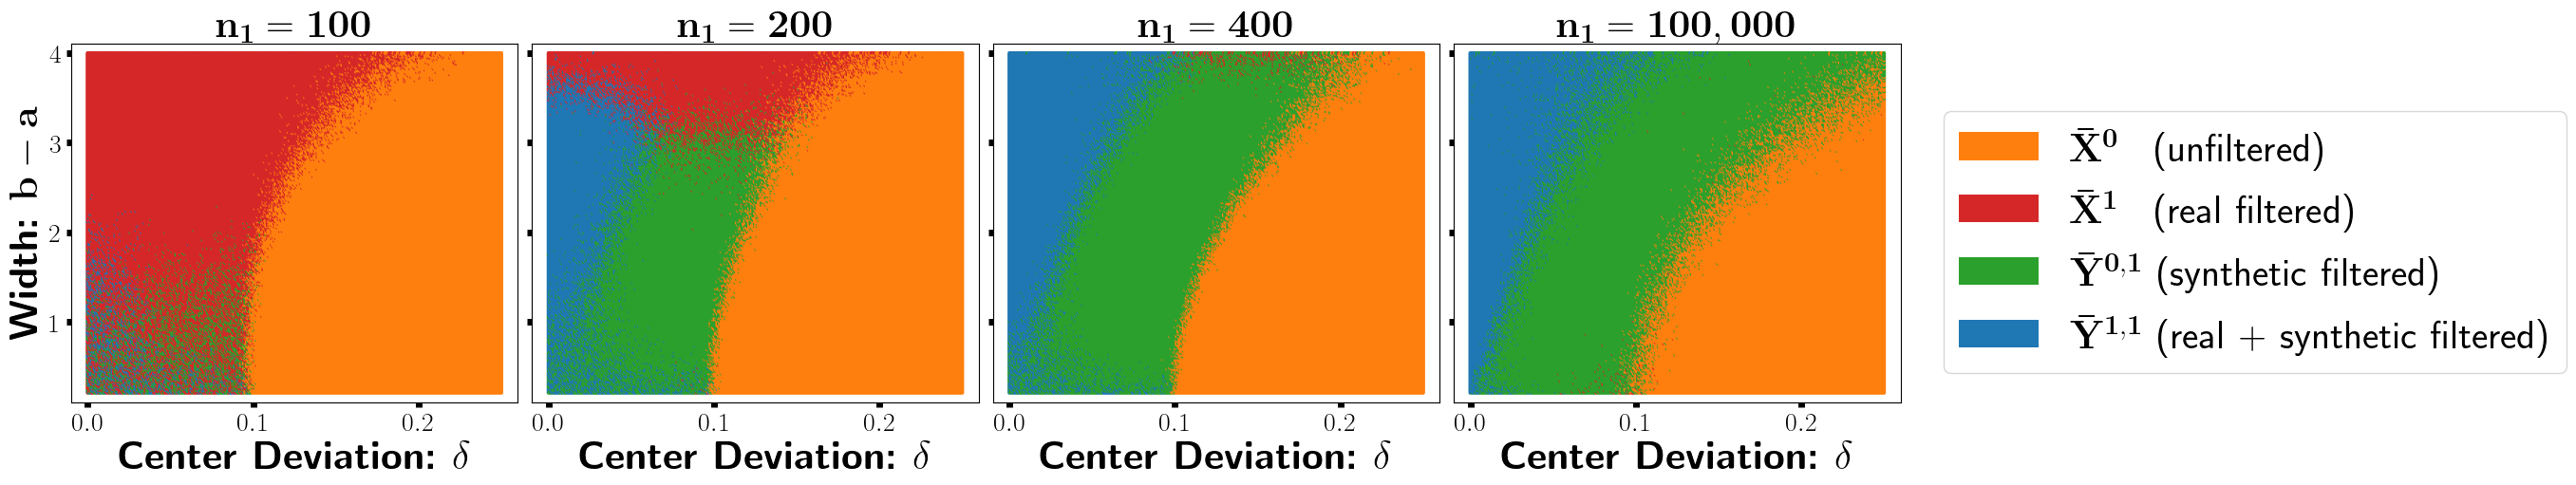

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import joblib

# --- Optional: Global font settings for bold text and ticks ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- Load data ---
emp_data_100 = joblib.load("simulation_results_n2100_1000.pkl")
emp_data_200 = joblib.load("simulation_results_n2200_1000.pkl")
emp_data_400 = joblib.load("simulation_results_n2400_1000.pkl")
emp_data_ify = joblib.load("simulation_results.pkl")

# --- Grid & filtering ---
n_bias, n_width = 300, 300
bias_vals = np.linspace(0, 0.25, n_bias)
width_vals = np.linspace(0.01, 4, n_width)
B, W = np.meshgrid(bias_vals, width_vals, indexing='ij')
bias_array = B.flatten()
width_array = W.flatten()
width_cut_mask = width_array >= 0.2
bias_array_cut = bias_array[width_cut_mask]
width_array_cut = width_array[width_cut_mask]

cmap = mcolors.ListedColormap(['#D62728', '#2CA02C', '#1F77B4', '#FF7F0E'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Panel titles ---
n2_labels = [r"$\mathbf{n_1 = 100}$", r"$\mathbf{n_1 = 200}$", r"$\mathbf{n_1 = 400}$", r"$\mathbf{n_1 = 100,000}$"]

legend_handles = [
    Patch(facecolor='#FF7F0E', label=r'$\mathbf{\bar{X}^0}$\hspace*{0.6em} (unfiltered)'),
    Patch(facecolor='#D62728', label=r'$\mathbf{\bar{X}^1}$\hspace*{0.6em}  (real filtered)'),
    Patch(facecolor='#2CA02C', label=r'$\mathbf{\bar{Y}^{0,1}}$\hspace*{0em} (synthetic filtered)'),
    Patch(facecolor='#1F77B4', label=r'$\mathbf{\bar{Y}^{1,1}}$\hspace*{0em} (real + synthetic filtered)'),
]

# --- Empirical Data ---
emp_data = [emp_data_100["which_min"], emp_data_200["which_min"],
            emp_data_400["which_min"], emp_data_ify["which_min"]]

# --- Create figure ---
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)

for j, ax in enumerate(axes2):
    which_flat = emp_data[j].flatten()
    which_cut = which_flat[width_cut_mask]

    ax.scatter(bias_array_cut, width_array_cut, c=which_cut,
               cmap=cmap, norm=norm, s=8, edgecolors='none')

    ax.set_title(n2_labels[j], fontsize=30, fontweight='bold')
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.1, 4.1)

    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Width:} $\mathbf{b - a}$', fontsize=30, fontweight='bold')

    # Bold tick numbers
    ax.tick_params(axis='both', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Shared legend (same as theoretical) ---
fig2.legend(handles=legend_handles,
            loc='center left',
            bbox_to_anchor=(1.01, 0.5),
            frameon=True,
            fontsize=30)

# --- Save as high-res vector PDF ---
fig2.savefig("fig_empirical_bold.png", bbox_inches='tight', dpi=300)
plt.show()


# Linear regression

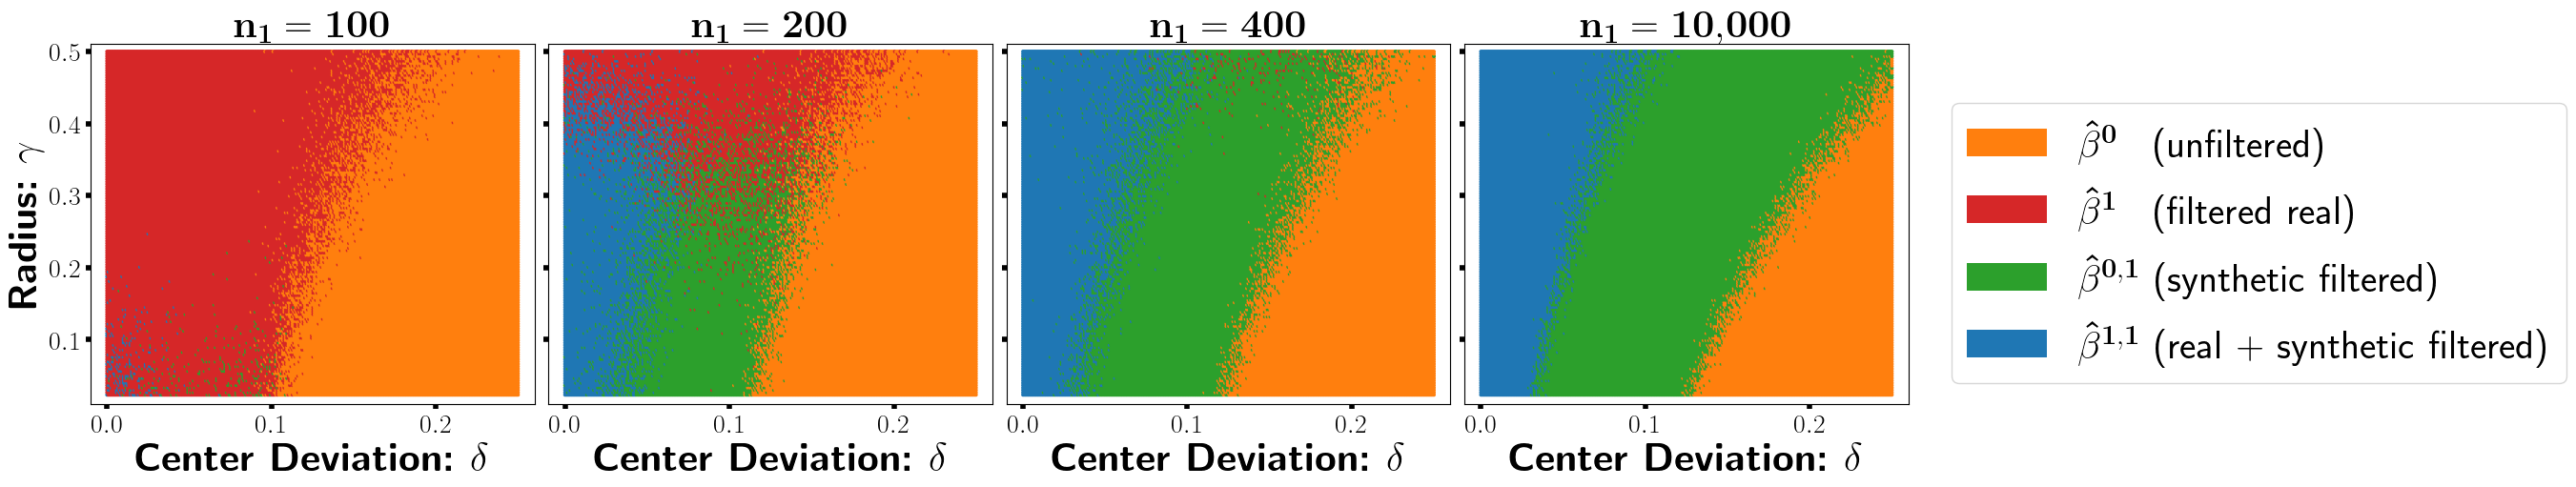

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import joblib

# --- Global plot style ---
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2

# --- Grid definitions (verifier center and radius) ---
n_center, n_radius = 300, 150
center_vals = np.linspace(0, 0.25, n_center)         # a in beta' = (a,...,a)
radius_vals = np.linspace(0.01, 0.5, n_radius)        # gamma in ||beta - beta'|| ≤ gamma
C, R = np.meshgrid(center_vals, radius_vals, indexing='ij')
center_array = C.flatten()
radius_array = R.flatten()
radius_cut_mask = radius_array >= 0.02
center_array_cut = center_array[radius_cut_mask]
radius_array_cut = radius_array[radius_cut_mask]

# --- Load simulation results for each n1 ---
results_100 = joblib.load("simulation_results_lr_n2100_2.pkl")
results_200 = joblib.load("simulation_results_lr_n2200_2.pkl")
results_400 = joblib.load("simulation_results_lr_n2400_2.pkl")
results_large = joblib.load("simulation_results_lr_n210000_2.pkl")

which_min_list = [
    results_100["which_min"],
    results_200["which_min"],
    results_400["which_min"],
    results_large["which_min"]
]

# --- Plot settings ---
cmap = mcolors.ListedColormap(['#D62728', '#2CA02C', '#1F77B4', '#FF7F0E'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

legend_handles = [
    Patch(facecolor='#FF7F0E', label=r'$\mathbf{\hat{\beta}^0}$ \hspace*{0.6em}(unfiltered)'),
    Patch(facecolor='#D62728', label=r'$\mathbf{\hat{\beta}^1}$ \hspace*{0.6em}(filtered real)'),
    Patch(facecolor='#2CA02C', label=r'$\mathbf{\hat{\beta}^{0,1}}$ (synthetic filtered)'),
    Patch(facecolor='#1F77B4', label=r'$\mathbf{\hat{\beta}^{1,1}}$ (real + synthetic filtered)'),
]

titles = [r"$\mathbf{n_1 = 100}$", r"$\mathbf{n_1 = 200}$", r"$\mathbf{n_1 = 400}$", r"$\mathbf{n_1 = 10{,}000}$"]

# --- Create figure ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)
for j, ax in enumerate(axes):
    which_flat = which_min_list[j].flatten()
    which_cut = which_flat[radius_cut_mask]

    ax.scatter(center_array_cut, radius_array_cut, c=which_cut,
               cmap=cmap, norm=norm, s=8, edgecolors='none')

    ax.set_title(titles[j], fontsize=30, fontweight='bold')
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(0.01, 0.51)

    ax.set_xlabel(r'\textbf{Center Deviation:} $\mathbf{\delta}$', fontsize=30, fontweight='bold')
    if j == 0:
        ax.set_ylabel(r'\textbf{Radius:} $\mathbf{\gamma}$', fontsize=30, fontweight='bold')

    ax.tick_params(axis='both', labelsize=20, width=4)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# --- Shared legend ---
fig.legend(handles=legend_handles,
           loc='center left',
           bbox_to_anchor=(1.01, 0.5),
           frameon=True,
           fontsize=30)

# --- Save plot ---
fig.savefig("fig_lr_verifier_grid.png", bbox_inches='tight', dpi=300)
plt.show()
